# Entrenamiento V6 - YOLOv11m (Pothole Detection)
**Clean & Organized Notebook**

Este notebook consolida todo el flujo de trabajo: Configuración, Entrenamiento y Análisis Avanzado.

## 1. Configuración Inicial (GPU & Rutas)
Solo ejecuta esto una vez al abrir el notebook.

In [62]:
import os
import torch
import shutil
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# --- 1. CONFIGURACIÓN DE GPU ---
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU Activa: {torch.cuda.get_device_name(0)}")
else:
    print("AVISO: Estás usando CPU.")

# --- 2. RUTAS DEL PROYECTO ---
PROJECT_DIR = r'C:\Users\Rayols\Desktop\potholes\Tesis_Potholes'
DATA_YAML = r'C:\Users\Rayols\Desktop\potholes\datasetprinciapll\datasetl\data.yaml'
DATASET_PATH = Path(r"C:\Users\Rayols\Desktop\potholes\datasetprinciapll\datasetl")

# CARPETA PARA REPORTES CENTRALIZADOS (Donde se guardarán tus imagenes)
REPORT_DIR = os.path.join(PROJECT_DIR, 'Reportes_Analisis')
os.makedirs(REPORT_DIR, exist_ok=True)
print(f"\n>>> TODAS LAS IMAGENES SE GUARDARÁN EN: {REPORT_DIR}")

# Ruta del ULTIMO entrenamiento realizado
LAST_RUN_DIR = os.path.join(PROJECT_DIR, 'Entrenamiento_V6_Extended_2_100e')

GPU Activa: NVIDIA GeForce RTX 3060 Ti

>>> TODAS LAS IMAGENES SE GUARDARÁN EN: C:\Users\Rayols\Desktop\potholes\Tesis_Potholes\Reportes_Analisis


## 2. Herramientas de Análisis (Funciones)
Aquí definimos todas las funciones para graficar y reportar. **Ejecuta esta celda para cargar las herramientas.**

In [63]:
def consolidar_historial(project_dir, save_dir):
    """Genera el grafico GLOBAL_PROGRESS uniendo todos los results.csv"""
    all_dfs = []
    epoch_offset = 0
    total_time_seconds = 0
    
    run_folders = [
        'Entrenamiento_V6_Medium_Stable_512px', # Run 1
        'Entrenamiento_V6_Extended_50e',        # Run 2
        'Entrenamiento_V6_Extended_2_100e',     # Run 3
        'Entrenamiento_V6_Extended_3_100e'      # Run 4 (Futuro)
    ]
    
    print("Generando historial global...")
    for folder in run_folders:
        csv_path = os.path.join(project_dir, folder, 'results.csv')
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df.columns = [c.strip() for c in df.columns]
            if 'time' in df.columns: total_time_seconds += df['time'].max()
            df['epoch'] = df['epoch'] + epoch_offset
            all_dfs.append(df)
            epoch_offset = df['epoch'].max() + 1

    if not all_dfs: return
    
    full_df = pd.concat(all_dfs, ignore_index=True)
    # Guardar CSV global tambien en reportes
    full_df.to_csv(os.path.join(save_dir, 'GLOBAL_RESULTS.csv'), index=False)
    
    # Graficar
    plt.figure(figsize=(10, 10))
    
    # Metricas
    plt.subplot(2, 1, 1)
    for metric in ['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)']:
        if metric in full_df.columns: plt.plot(full_df['epoch'], full_df[metric], label=metric)
    plt.title(f'Progreso Global ({epoch_offset} épocas)')
    plt.legend(); plt.grid(True, alpha=0.3)
    
    # Loss
    plt.subplot(2, 1, 2)
    for loss in ['train/box_loss', 'val/box_loss', 'train/seg_loss', 'val/seg_loss']:
        if loss in full_df.columns:
            style = '--' if 'train' in loss else '-'
            plt.plot(full_df['epoch'], full_df[loss], label=loss, linestyle=style)
    plt.title('Curvas de Pérdida (Loss)')
    plt.legend(); plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_path = os.path.join(save_dir, 'GLOBAL_PROGRESS.png')
    plt.savefig(save_path)
    print(f"Historial Global guardado en: {save_path}")
    plt.show()

def reporte_mejor_epoca(run_path, save_dir):
    """Analisa metrics y guarda reporte"""
    csv_path = os.path.join(run_path, 'results.csv')
    if not os.path.exists(csv_path): return

    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    best_idx = df['metrics/mAP50(B)'].idxmax()
    best_row = df.loc[best_idx]
    
    print("\n=== REPORTE DE MEJOR ÉPOCA ===")
    # Guardar en texto
    txt_path = os.path.join(save_dir, 'BEST_EPOCH_REPORT.txt')
    with open(txt_path, 'w') as f:
        f.write(f"Reporte generado desde: {run_path}\n")
        f.write(f"Mejor Epoca: {int(best_row['epoch'])}\n")
        for col in df.columns:
            line = f"{col}: {best_row[col]:.5f}"
            print(line)
            f.write(line + '\n')
    print(f"(Guardado en {txt_path})")
    print("================================")

def probar_inferencia(run_dir, data_path, label, num_samples=3):
    """Prueba el modelo con imagenes aleatorias"""
    weights = os.path.join(run_dir, 'weights', 'best.pt')
    if not os.path.exists(weights): weights = os.path.join(run_dir, 'weights', 'last.pt')
    
    if not os.path.exists(weights): 
        print("No se encontraron pesos para probar."); return

    print(f"\n>>> Probando {label} ({num_samples} imgs)...")
    model = YOLO(weights)
    
    import random
    images = list(Path(data_path).glob('*.jpg'))
    if not images: return
    
    samples = random.sample(images, min(num_samples, len(images)))
    
    for img in samples:
        res = model.predict(img, save=False, verbose=False)
        for r in res:
            im_array = r.plot()
            plt.figure(figsize=(6,4))
            plt.imshow(im_array[..., ::-1])
            plt.title(f"{label}: {img.name}"); plt.axis('off'); plt.show()

## 3. Ejecutar Análisis y Centralizar Resultados
Esta celda generará los gráficos y **COPIARÁ todo a la carpeta `Reportes_Analisis`** para que lo encuentres fácil.

Generando historial global...
Historial Global guardado en: C:\Users\Rayols\Desktop\potholes\Tesis_Potholes\Reportes_Analisis\GLOBAL_PROGRESS.png


<Figure size 1000x1000 with 2 Axes>


=== REPORTE DE MEJOR ÉPOCA ===
epoch: 100.00000
time: 79148.90000
train/box_loss: 0.34428
train/seg_loss: 0.18908
train/cls_loss: 0.19282
train/dfl_loss: 0.42588
metrics/precision(B): 0.85648
metrics/recall(B): 0.73081
metrics/mAP50(B): 0.84466
metrics/mAP50-95(B): 0.48959
metrics/precision(M): 0.84947
metrics/recall(M): 0.72342
metrics/mAP50(M): 0.83453
metrics/mAP50-95(M): 0.46848
val/box_loss: 0.14569
val/seg_loss: 0.07986
val/cls_loss: 0.09122
val/dfl_loss: 0.15845
lr/pg0: 0.00010
lr/pg1: 0.00010
lr/pg2: 0.00010
(Guardado en C:\Users\Rayols\Desktop\potholes\Tesis_Potholes\Reportes_Analisis\BEST_EPOCH_REPORT.txt)

--- Copiando Gráficos a Reportes_Analisis ---
Copiado: confusion_matrix.png


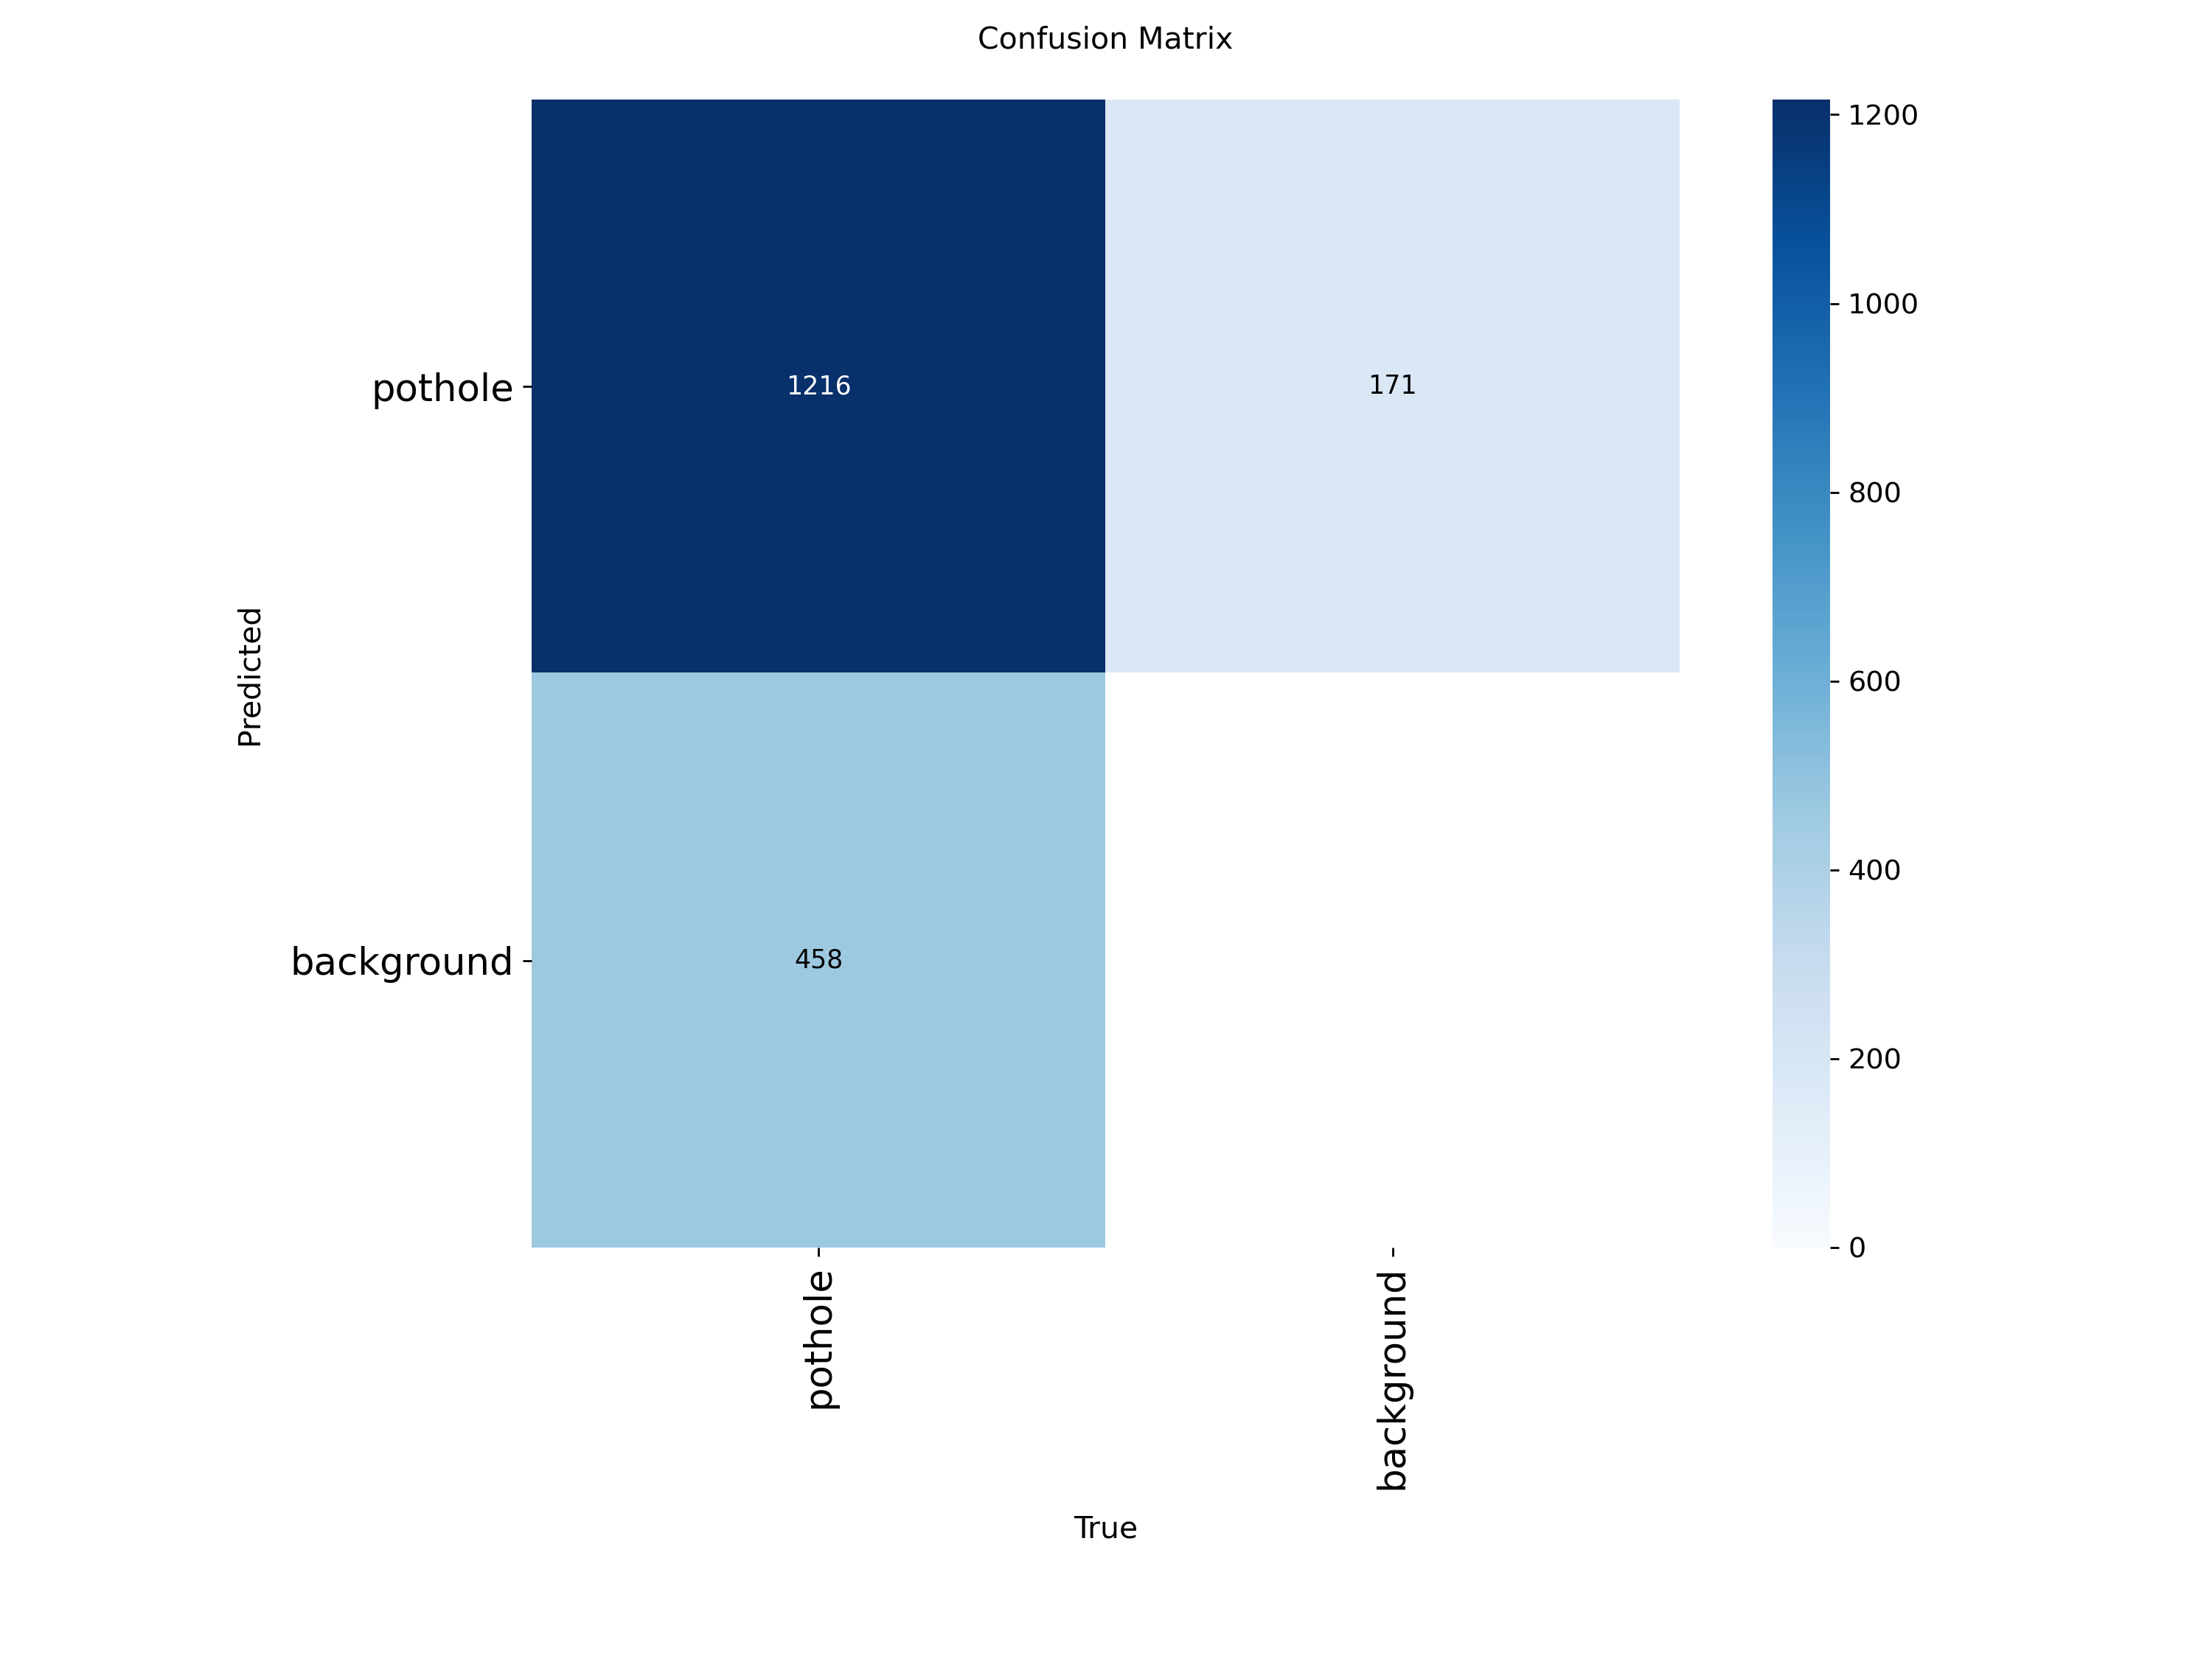

Copiado: confusion_matrix_normalized.png


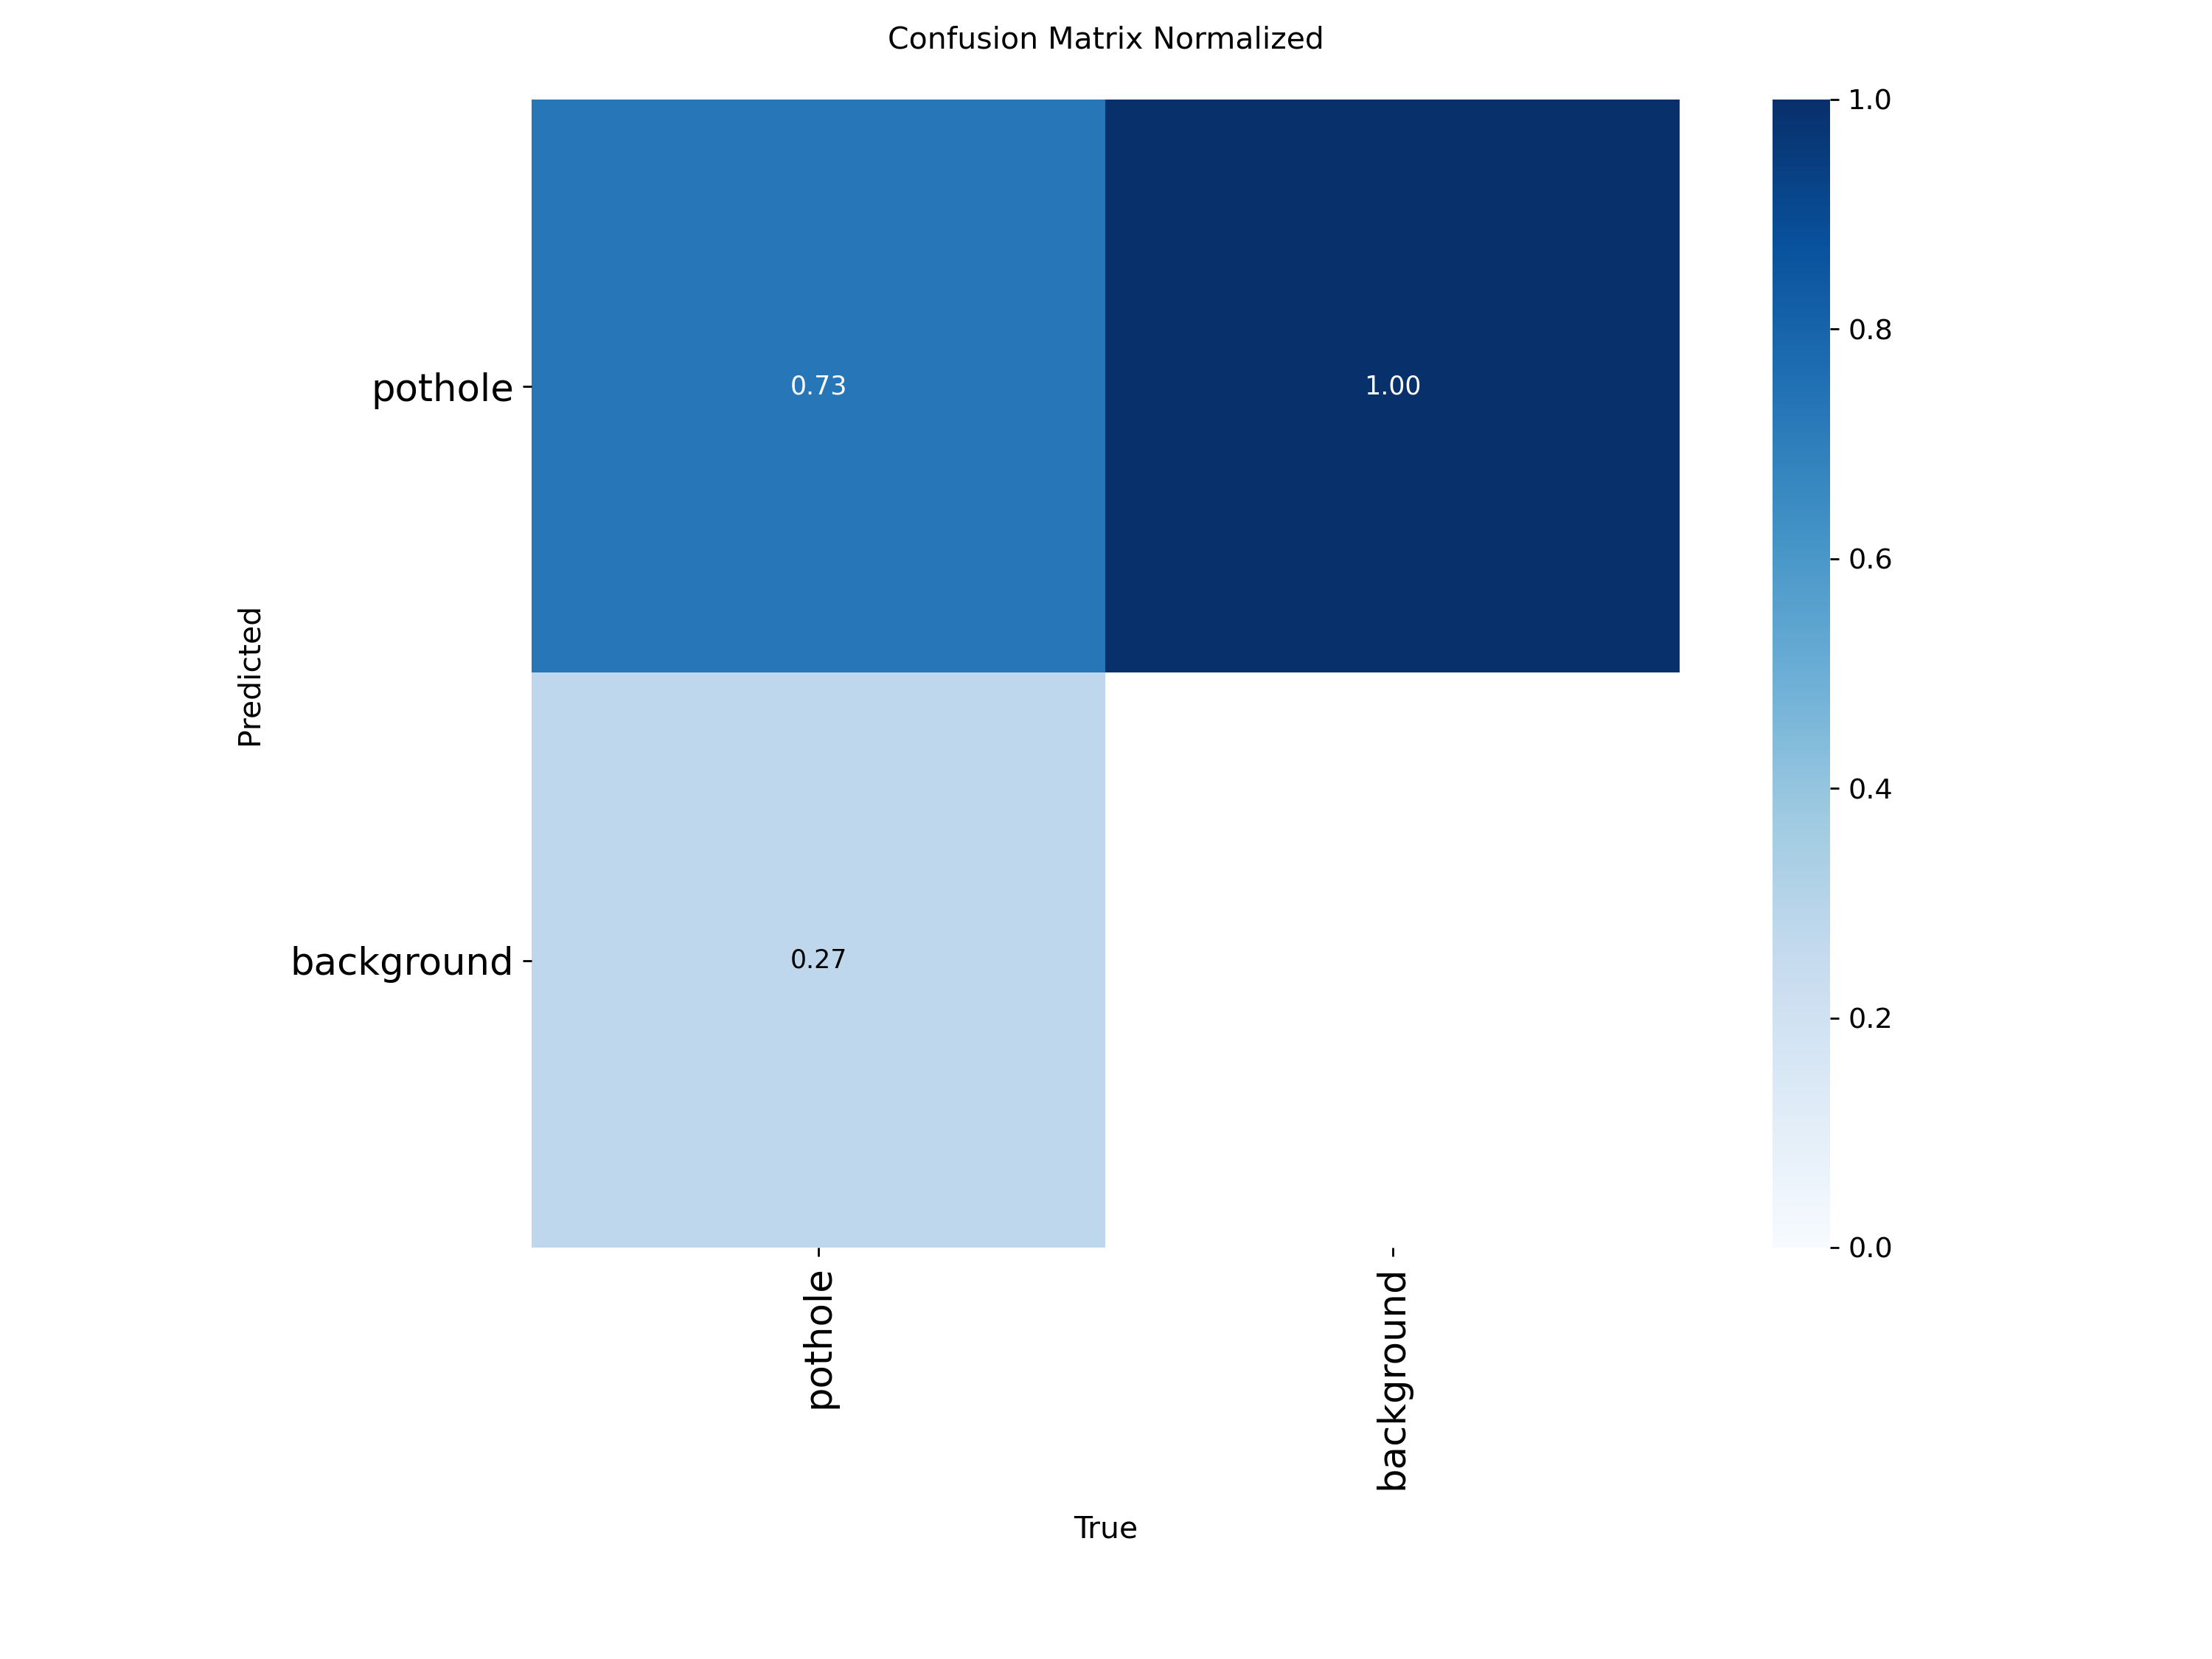

Copiado: results.png


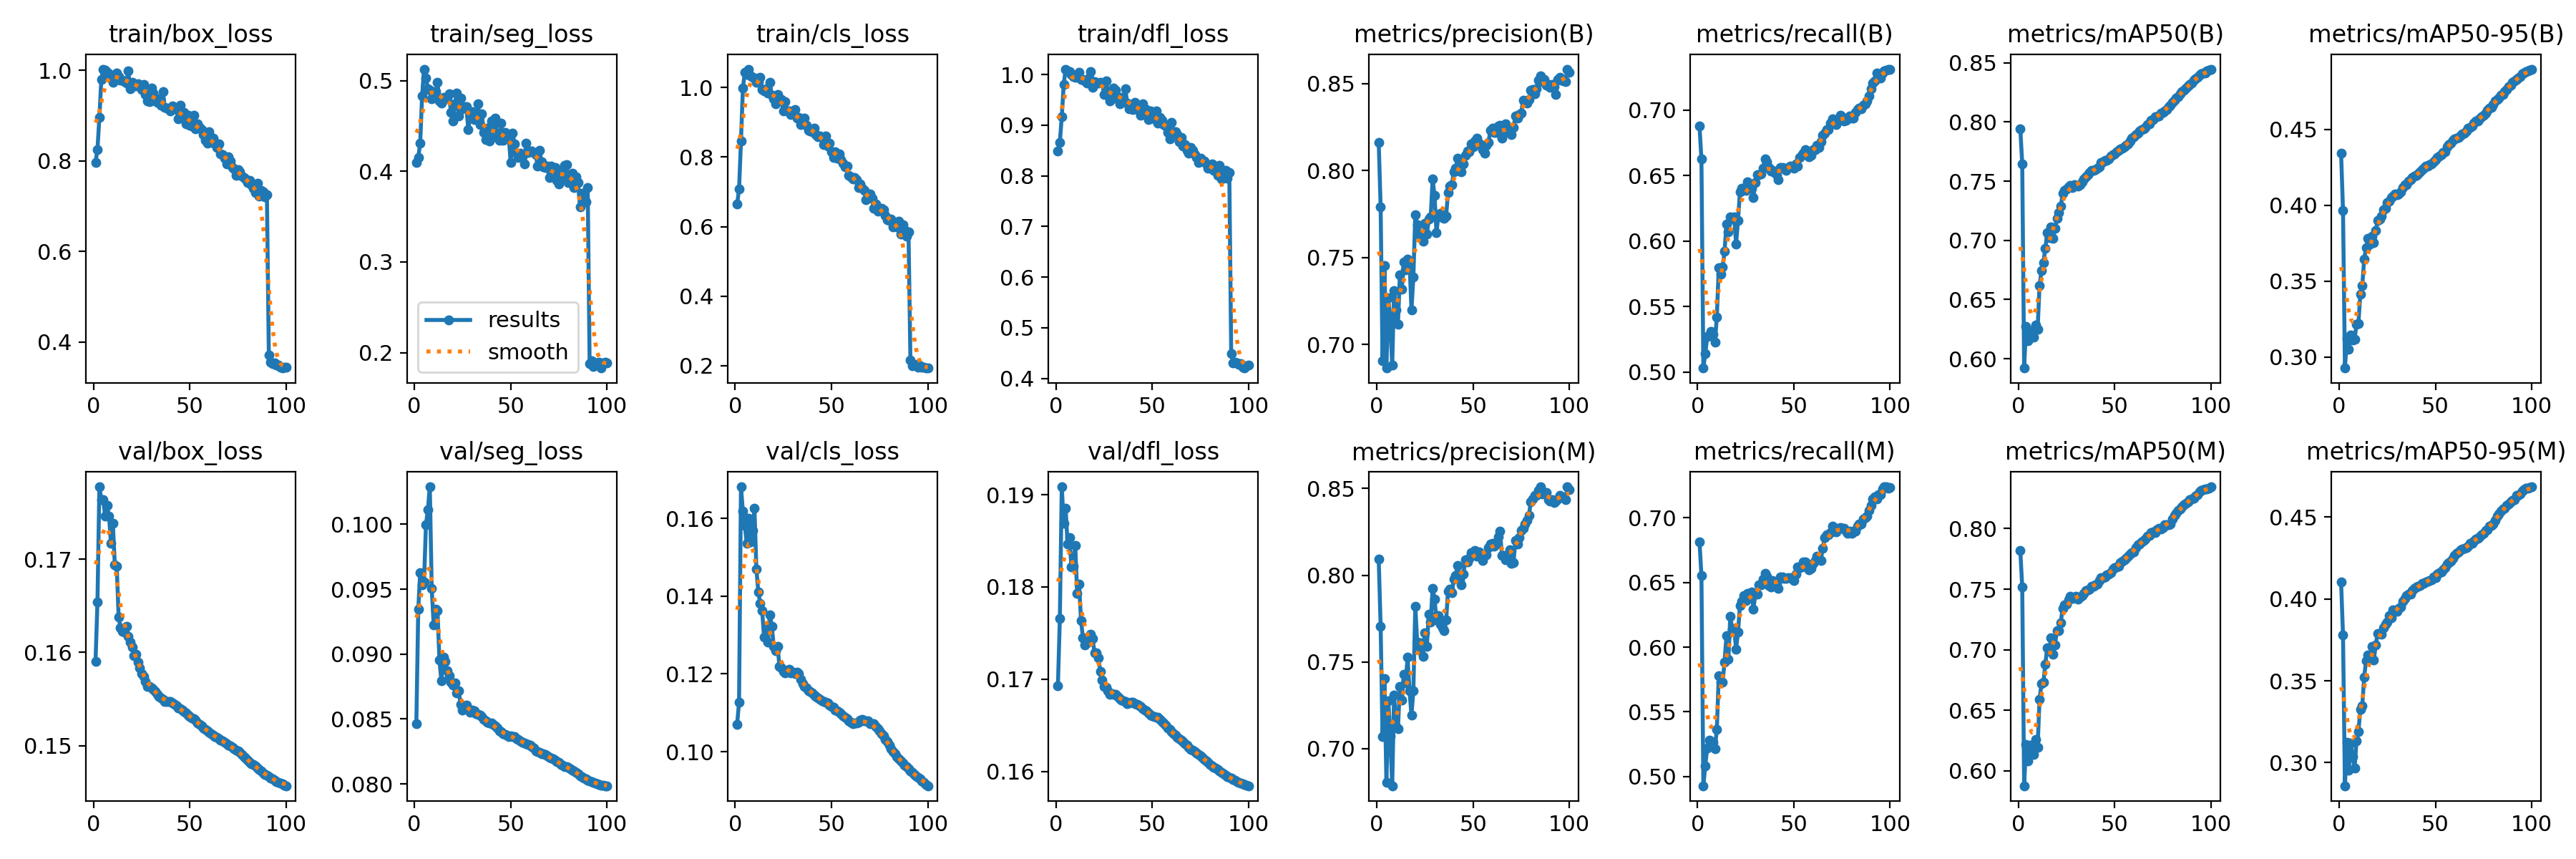

Copiado: val_batch0_pred.jpg


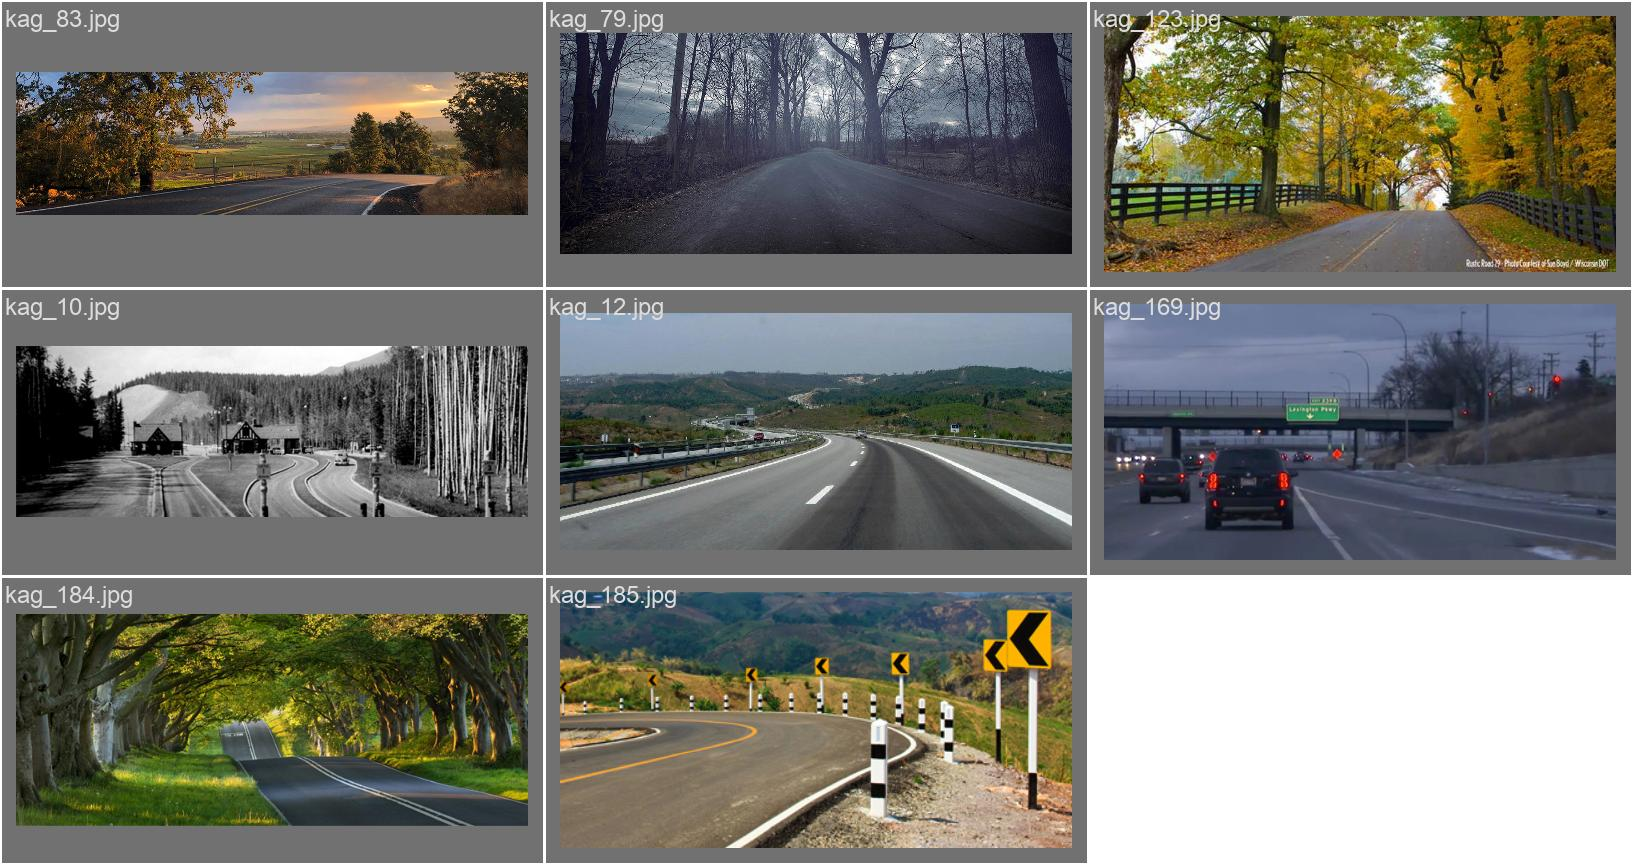


>>> Probando VALIDACION (3 imgs)...


<Figure size 600x400 with 1 Axes>

<Figure size 600x400 with 1 Axes>

<Figure size 600x400 with 1 Axes>


>>> Probando ENTRENAMIENTO (3 imgs)...


<Figure size 600x400 with 1 Axes>

<Figure size 600x400 with 1 Axes>

<Figure size 600x400 with 1 Axes>

In [64]:
# 1. Historial Global
consolidar_historial(PROJECT_DIR, REPORT_DIR)

# 2. Métricas del último entrenamiento
reporte_mejor_epoca(LAST_RUN_DIR, REPORT_DIR)

# 3. Copiar Gráficos Clave a la carpeta de Reportes
charts_to_copy = [
    'confusion_matrix.png', 
    'confusion_matrix_normalized.png', 
    'results.png',
    'val_batch0_pred.jpg'
]
print("\n--- Copiando Gráficos a Reportes_Analisis ---")
for chart in charts_to_copy:
    src = os.path.join(LAST_RUN_DIR, chart)
    dst = os.path.join(REPORT_DIR, chart)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"Copiado: {chart}")
        display(Image(filename=dst, width=600))
    else:
        print(f"[!] No encontrado: {chart}")

# 4. Inferencia Manual (Visual)
val_path = DATASET_PATH / 'val' / 'images'
train_path = DATASET_PATH / 'train' / 'images'
probar_inferencia(LAST_RUN_DIR, val_path, "VALIDACION")
probar_inferencia(LAST_RUN_DIR, train_path, "ENTRENAMIENTO")

## 4. Visualización del Dataset

In [65]:
train_dir = DATASET_PATH / 'train' / 'images'
val_dir = DATASET_PATH / 'val' / 'images'
test_dir = DATASET_PATH / 'test' / 'images'

counts = {}
if train_dir.exists(): counts['Train'] = len(list(train_dir.glob('*.*')))
if val_dir.exists(): counts['Val'] = len(list(val_dir.glob('*.*')))
if test_dir.exists(): counts['Test'] = len(list(test_dir.glob('*.*')))

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.1f}%\n({v:d})'.format(p=pct, v=val)
    return my_autopct

if counts:
    plt.figure(figsize=(6, 6))
    plt.pie(counts.values(), labels=counts.keys(), autopct=make_autopct(counts.values()), 
            colors=['#ff9999','#66b3ff','#99ff99'], shadow=True)
    plt.title(f"Dataset Total: {sum(counts.values())}")
    
    # Guardar en Reportes
    save_p = os.path.join(REPORT_DIR, 'DATASET_SPLIT_PIE.png')
    plt.savefig(save_p)
    plt.show()
    print(f"Guardado en: {save_p}")

<Figure size 600x600 with 1 Axes>

Guardado en: C:\Users\Rayols\Desktop\potholes\Tesis_Potholes\Reportes_Analisis\DATASET_SPLIT_PIE.png


## 5. Próximo Paso: Extensión 3 (100 Épocas más)
**NO EJECUTAR** a menos que quieras iniciar el entrenamiento de horas.
Esto retomará desde donde quedó la Extensión 2.

In [ ]:
# Configuración Extensión 3
last_weight = os.path.join(LAST_RUN_DIR, 'weights', 'last.pt')
PROJECT_NAME = 'Tesis_Potholes'

print(f"Preparando extensión desde: {last_weight}")
model = YOLO(last_weight)

# Iniciar Entrenamiento
results = model.train(
    data=DATA_YAML,
    project=PROJECT_NAME,
    name='Entrenamiento_V6_Extended_3_100e',
    epochs=100,      # 100 epocas mas
    patience=0,      # Sin early stopping
    batch=4,
    imgsz=512,
    device=0,
    workers=2,
    optimizer='auto',
    lr0=0.005,
    lrf=0.01,
    cos_lr=True,
    exist_ok=True,
    save=True,
    plots=True,
    amp=True
)